[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Biswajit1999/daily-astro-notebooks/blob/master/sdss/2026-07-30-galaxy-redshift-slice/notebook.ipynb)

# A slice through the galaxy redshift survey -- SDSS's own 'cone diagram'

One of the most famous plots in cosmology is the 'cone diagram': a thin wedge of sky where every galaxy is plotted by its redshift (a stand-in for distance) and position, revealing the cosmic web of filaments and voids. I wanted to make a small version of that myself with a real SDSS galaxy sample slice.

In [1]:
from astroquery.sdss import SDSS
import numpy as np
import matplotlib.pyplot as plt

query = '''
SELECT TOP 3000 ra, dec, z
FROM specObj
WHERE class = 'GALAXY' AND dec BETWEEN -1.25 AND 1.25 AND z BETWEEN 0 AND 0.3
'''
tab = SDSS.query_sql(query)
print(len(tab), 'galaxies retrieved')

3000 galaxies retrieved


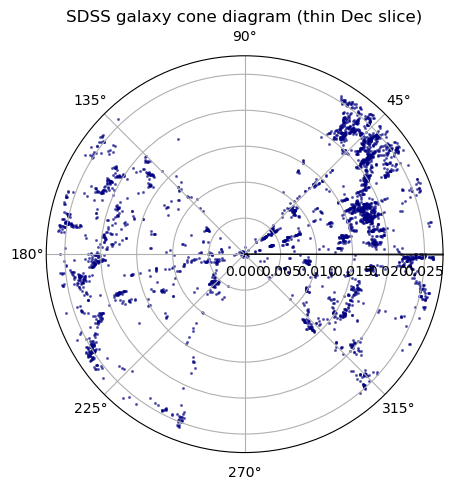

In [2]:
ra = np.array(tab['ra'])
z = np.array(tab['z'])
theta = np.deg2rad(ra)

plt.figure(figsize=(9,5))
ax = plt.subplot(111, projection='polar')
ax.scatter(theta, z, s=1.5, alpha=0.5, color='navy')
ax.set_thetamin(np.rad2deg(theta.min()))
ax.set_thetamax(np.rad2deg(theta.max()))
ax.set_rlabel_position(135)
plt.title('SDSS galaxy cone diagram (thin Dec slice)')
plt.tight_layout()
plt.savefig('cone_diagram.png', dpi=120)
plt.show()

Even in this narrow declination strip you can see galaxies aren't spread evenly -- they clump into denser strands with darker, emptier gaps between them. That clumpy pattern is the cosmic web, the large-scale structure gravity has pulled matter into over billions of years.

**What I'd look at next:** Widen the redshift range and add a second declination slice to compare how the web pattern's characteristic scale changes with distance.

**Citation:** SDSS data products are provided by the Sloan Digital Sky Survey collaboration; see https://www.sdss.org/collaboration/citing-sdss/.